In [1]:
from pathlib import Path
from PIL import Image
import pandas as pd

PROJECT_ROOT = Path("..")
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

classes = [
    "comedonal_closed",
    "comedonal_open",
    "inflammatory_acne",
    "acne_scars"
]

IMG_SIZE = (224, 224)
image_extensions = [".jpg", ".jpeg", ".png", ".webp"]

In [2]:
def resize_with_padding(image, target_size=(224, 224), fill_color=(0, 0, 0)):
    """
    Resize an image while preserving its aspect ratio, then pad it to the target size.
    Note this is resizing and not cropping
    """
    image = image.convert("RGB")
    image.thumbnail(target_size)

    new_image = Image.new("RGB", target_size, fill_color)

    x_offset = (target_size[0] - image.width) // 2
    y_offset = (target_size[1] - image.height) // 2

    new_image.paste(image, (x_offset, y_offset))

    return new_image

In [3]:
processed_records = []

for class_name in classes:
    raw_class_dir = RAW_DIR / class_name
    processed_class_dir = PROCESSED_DIR / class_name
    processed_class_dir.mkdir(parents=True, exist_ok=True)

    image_paths = [
        path for path in raw_class_dir.iterdir()
        if path.suffix.lower() in image_extensions
    ]

    for i, image_path in enumerate(image_paths, start=1):
        try:
            img = Image.open(image_path)
            processed_img = resize_with_padding(img, IMG_SIZE)

            output_filename = f"{class_name}_{i:04d}.jpg"
            output_path = processed_class_dir / output_filename

            processed_img.save(output_path, "JPEG", quality=95)

            processed_records.append({
                "original_path": str(image_path),
                "processed_path": str(output_path),
                "label": class_name
            })

        except Exception as e:
            print(f"Error processing {image_path}: {e}")

processed_df = pd.DataFrame(processed_records)
processed_df.head()

,original_path,processed_path,label
0,..\data\raw\comedonal_closed\come_001.png,..\data\processed\comedonal_closed\comedonal_c...,comedonal_closed
1,..\data\raw\comedonal_closed\come_002.png,..\data\processed\comedonal_closed\comedonal_c...,comedonal_closed
2,..\data\raw\comedonal_closed\come_003.png,..\data\processed\comedonal_closed\comedonal_c...,comedonal_closed
3,..\data\raw\comedonal_closed\come_004.png,..\data\processed\comedonal_closed\comedonal_c...,comedonal_closed
4,..\data\raw\comedonal_closed\come_005.png,..\data\processed\comedonal_closed\comedonal_c...,comedonal_closed


In [4]:
processed_df.to_csv(PROCESSED_DIR / "labels.csv", index=False)

In [5]:
processed_df.count()

original_path     204
processed_path    204
label             204
dtype: int64

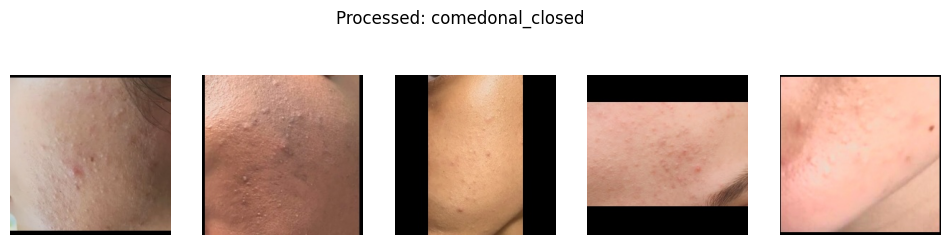

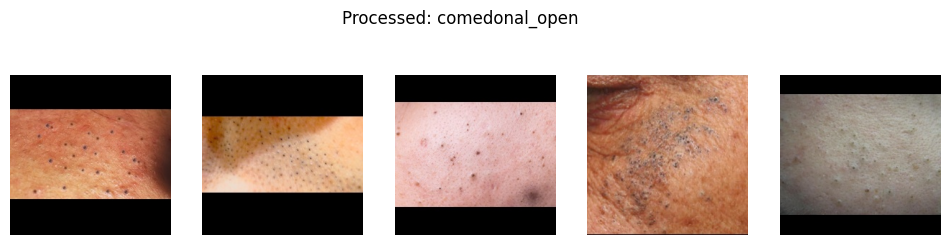

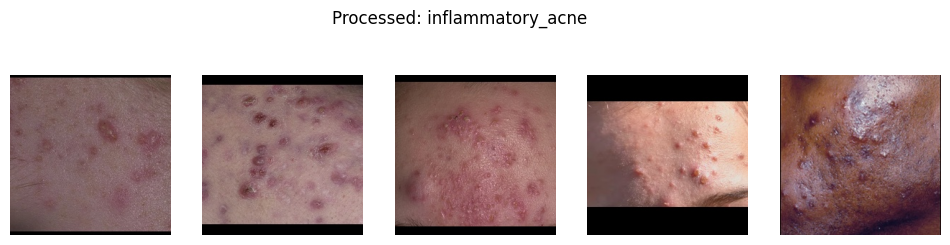

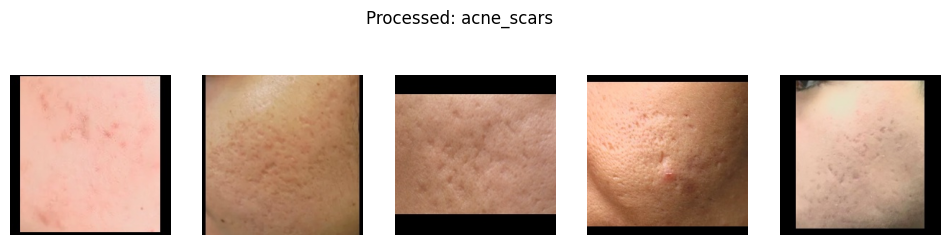

In [6]:
import matplotlib.pyplot as plt

for class_name in classes:
    sample_paths = processed_df[processed_df["label"] == class_name]["processed_path"].sample(
        min(5, len(processed_df[processed_df["label"] == class_name])),
        random_state=42
    )

    plt.figure(figsize=(12, 3))
    plt.suptitle(f"Processed: {class_name}")

    for i, path in enumerate(sample_paths):
        img = Image.open(path)
        plt.subplot(1, 5, i + 1)
        plt.imshow(img)
        plt.axis("off")

    plt.show()